In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [2]:
results_folder = "../results/ColorAnalysis/2D"
create_folder(results_folder)

Folder already exists: ../results/ColorAnalysis/2D


In [3]:
df_dynamic = pd.read_csv("../SOP_data/all_colors_dynamic.dat", sep=' ')
df_dynamic

,type_perc,dim,L,f_T,c,num_colors,P0,p0,N_samples,rho,nc,nc_err,nc_std,stat_window
0,bond,2,1024,0.001000,0.01,1,0.5,0.8,606,1.00,0.0,0.0,0.0,300
1,bond,2,2048,0.001000,0.01,1,0.5,0.8,306,1.00,0.0,0.0,0.0,300
2,bond,2,4096,0.001000,0.01,1,0.5,0.8,156,1.00,0.0,0.0,0.0,300
3,bond,2,8192,0.001000,0.01,1,0.5,0.8,81,1.00,0.0,0.0,0.0,300
4,bond,2,1024,0.005308,0.01,1,0.5,0.8,404,1.00,0.0,0.0,0.0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7427,bond,3,1024,0.473737,0.20,4,1.0,0.6,5,0.25,4.0,0.0,0.0,300
7428,bond,3,128,0.500000,0.20,4,1.0,0.6,200,0.25,4.0,0.0,0.0,300
7429,bond,3,256,0.500000,0.20,4,1.0,0.6,150,0.25,4.0,0.0,0.0,300
7430,bond,3,512,0.500000,0.20,4,1.0,0.6,25,0.25,4.0,0.0,0.0,300


In [4]:
df_series = pd.read_csv('../SOP_data/all_data_dynamic.dat', sep=' ')
df_series

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,...,N_samples_perc,p_mean,p_err,f_mean,f_err,z_max_mean,z_max_err,z_stat_mean,z_stat_err,stat_window
0,bond,2,8192,0.022538,0.01,1,1.00,0.8,0.5,0,...,1,0.501080,0.000000,0.022540,0.000000,8192.0,0.0,391.000000,0.000000,300
1,bond,2,8192,0.026846,0.01,1,1.00,0.8,0.5,0,...,2,0.501816,0.000865,0.026897,0.000006,8192.0,0.0,328.000000,12.000000,300
2,bond,2,4096,0.031154,0.01,1,1.00,0.8,0.5,0,...,1,0.501357,0.000000,0.031115,0.000000,4096.0,0.0,294.000000,0.000000,300
3,bond,2,8192,0.031154,0.01,1,1.00,0.8,0.5,0,...,3,0.501402,0.000317,0.031213,0.000025,8192.0,0.0,355.666667,4.666667,300
4,bond,2,4096,0.035462,0.01,1,1.00,0.8,0.5,0,...,4,0.501608,0.000648,0.035541,0.000043,4096.0,0.0,301.000000,12.935739,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16104,bond,3,512,0.500000,0.20,4,0.25,0.6,1.0,3,...,25,1.000000,0.000000,0.250196,0.000191,512.0,0.0,320.000000,0.000000,300
16105,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,0,...,5,1.000000,0.000000,0.250027,0.000210,1024.0,0.0,320.000000,0.000000,300
16106,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,1,...,5,1.000000,0.000000,0.250014,0.000276,1024.0,0.0,320.000000,0.000000,300
16107,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,2,...,5,1.000000,0.000000,0.250026,0.000280,1024.0,0.0,320.000000,0.000000,300


ns=1 | c=0.01 | rho=1.00000 | ft_min=0.164692 | ft_max=0.400000
ns=1 | c=0.05 | rho=1.00000 | ft_min=0.190000 | ft_max=0.400000
ns=1 | c=0.10 | rho=1.00000 | ft_min=0.151769 | ft_max=0.400000
ns=1 | c=0.15 | rho=1.00000 | ft_min=0.164692 | ft_max=0.400000
ns=1 | c=0.20 | rho=1.00000 | ft_min=0.160385 | ft_max=0.400000
ns=2 | c=0.01 | rho=0.50000 | ft_min=0.156077 | ft_max=0.400000
ns=2 | c=0.05 | rho=0.50000 | ft_min=0.138846 | ft_max=0.400000
ns=2 | c=0.10 | rho=0.50000 | ft_min=0.143154 | ft_max=0.400000
ns=2 | c=0.15 | rho=0.50000 | ft_min=0.134539 | ft_max=0.400000
ns=2 | c=0.20 | rho=0.50000 | ft_min=0.143154 | ft_max=0.400000
ns=3 | c=0.01 | rho=0.33333 | ft_min=0.121615 | ft_max=0.316000
ns=3 | c=0.05 | rho=0.33333 | ft_min=0.121615 | ft_max=0.316000
ns=3 | c=0.10 | rho=0.33333 | ft_min=0.113000 | ft_max=0.316000
ns=3 | c=0.15 | rho=0.33333 | ft_min=0.117308 | ft_max=0.316000
ns=3 | c=0.20 | rho=0.33333 | ft_min=0.121615 | ft_max=0.316000
ns=4 | c=0.01 | rho=0.25000 | ft_min=0.1

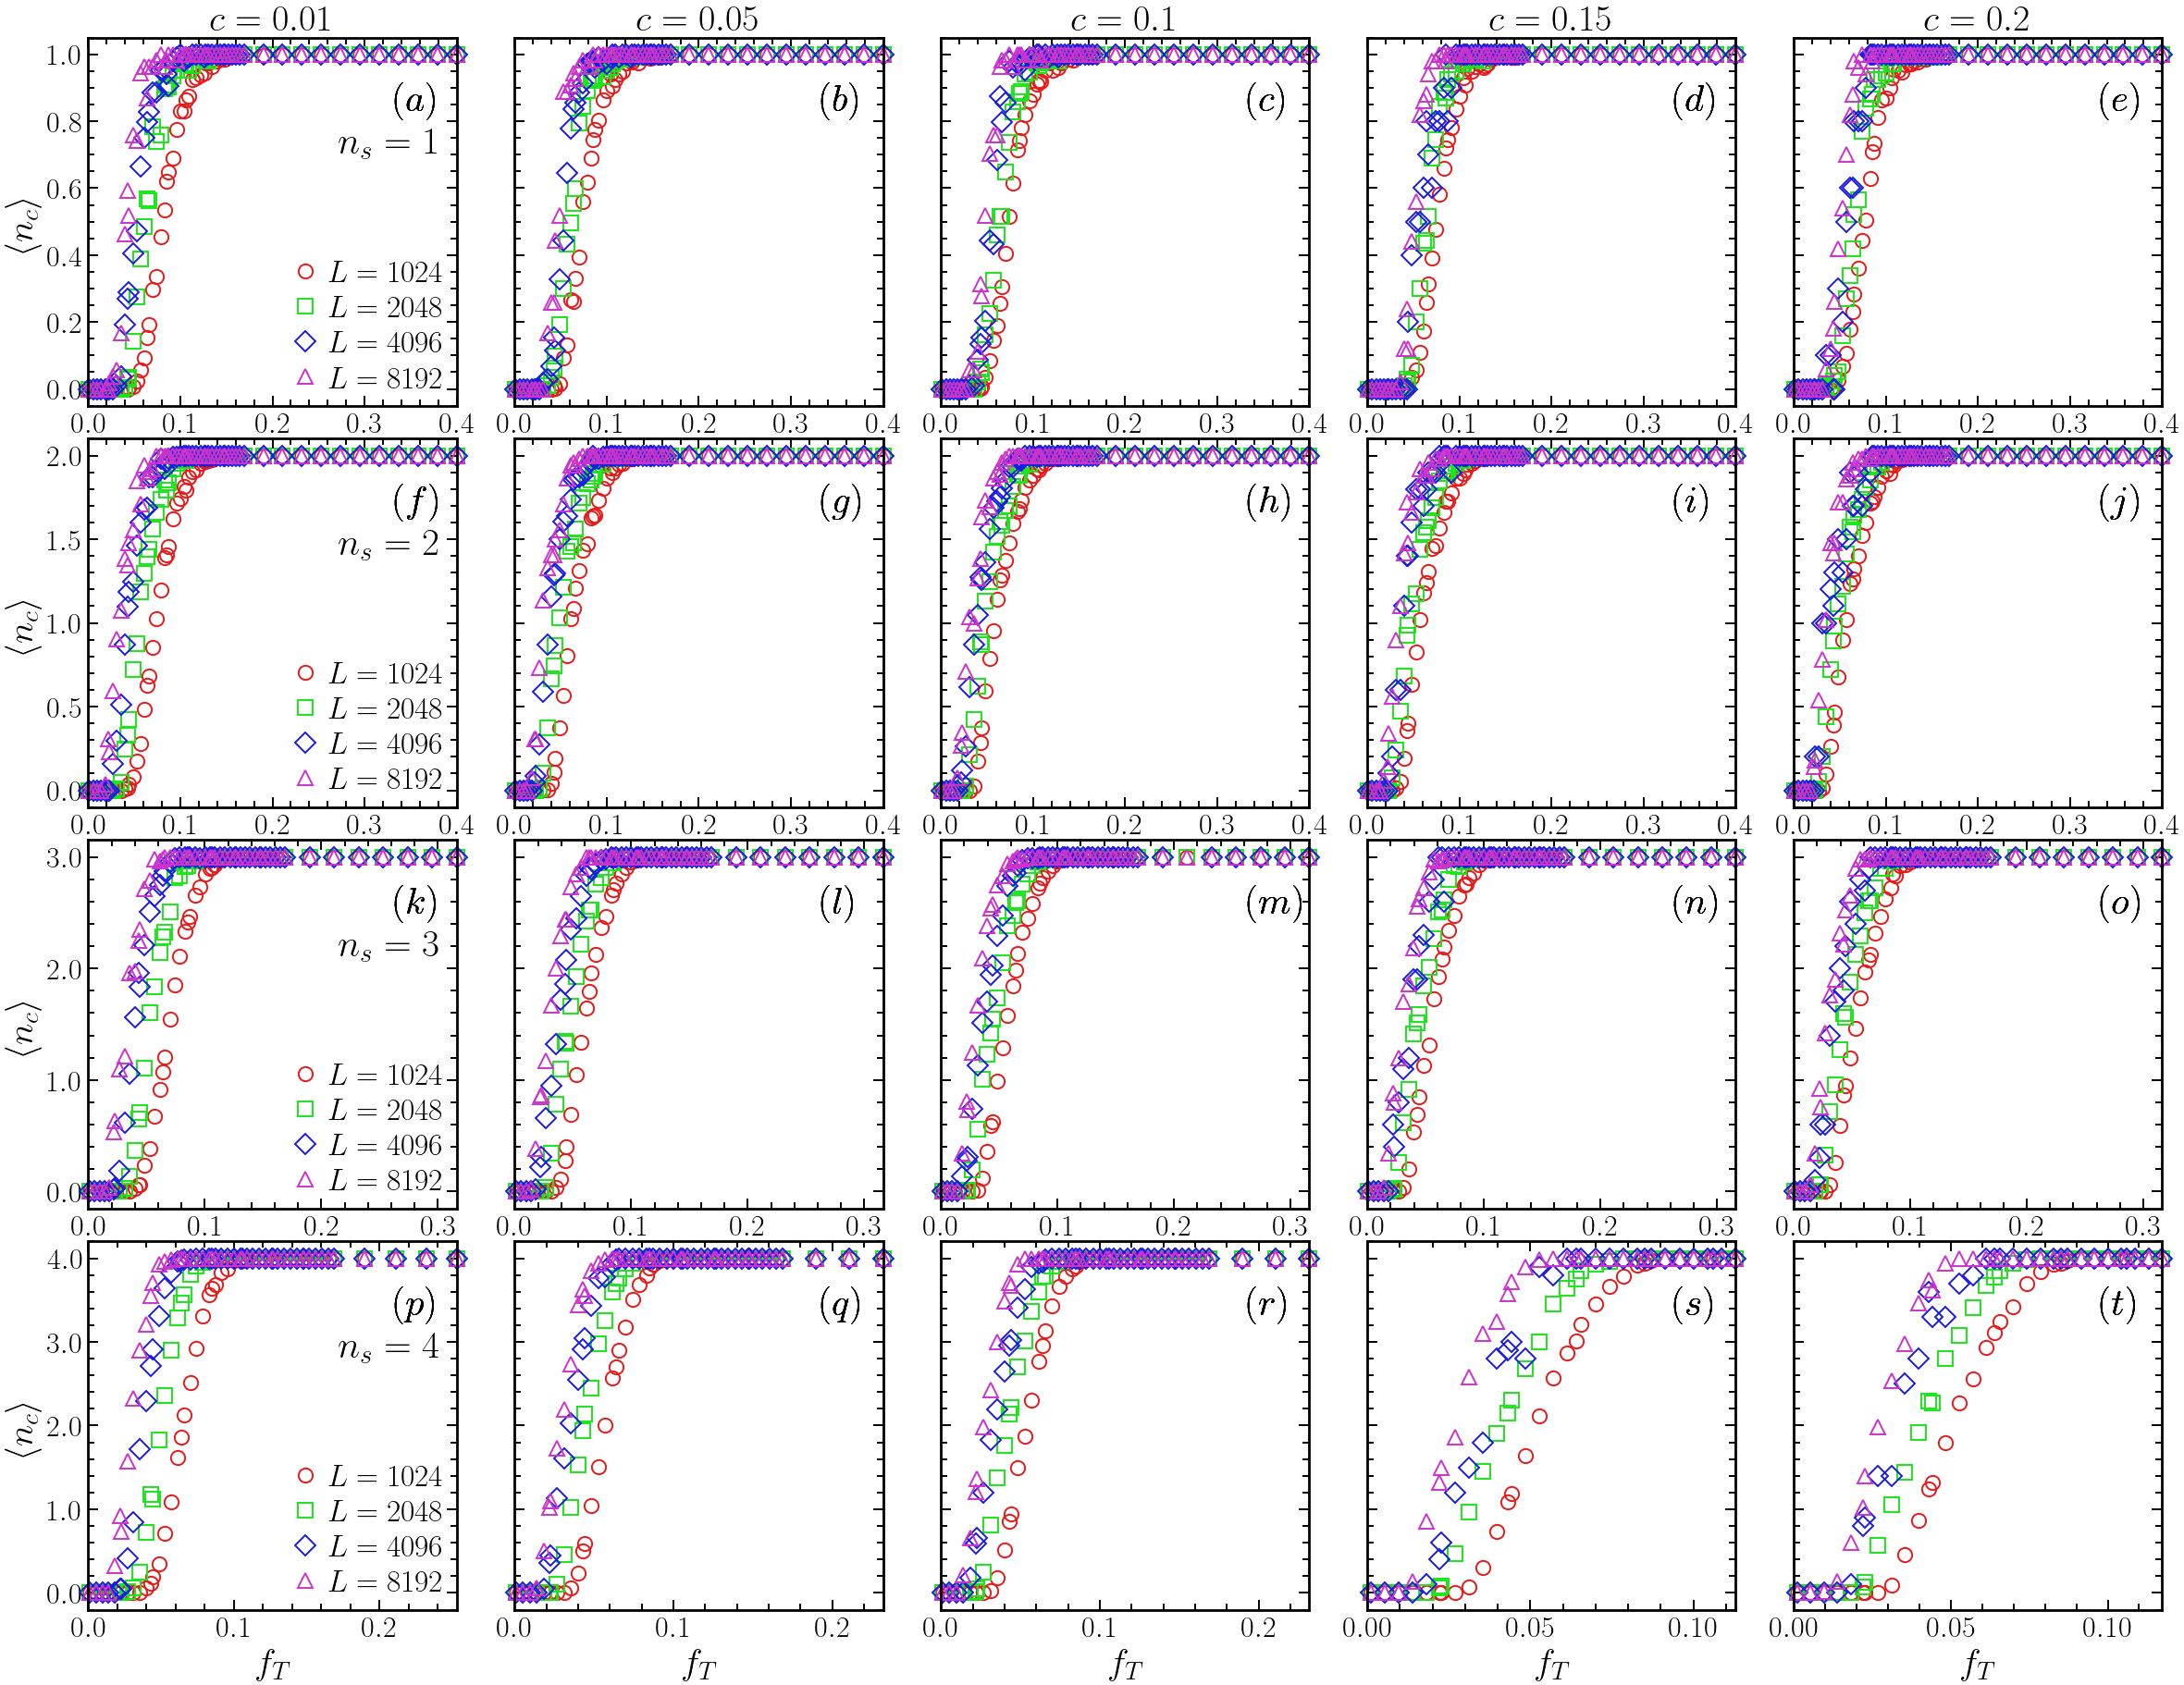

In [14]:
# PLOT <N_S>
fig, axes, parms, ft_bounds = plot_nc_dynamic_grid(
    df_dynamic=df_dynamic,
    df_series=df_series,
    L_lst=[1024, 2048, 4096, 8192],
    ns_lst=[1, 2, 3, 4],
    c_lst=[0.01, 0.05, 0.1, 0.15, 0.2],
    window=300,
    base=5,
    dim=2,
    order=0,
    p0=0.8,
    wspace=0.01,
    hspace=0.09,
    legend_loc='lower right',
    tick_fs=23,
    label_fs=29,
    title_fs=29,
    ms=11,
    mew=1.4,
    print_bounds=True,
    fs_legend=24,
    ns_text_x=0.68,
    ns_text_y=0.76,
    ns_text_fs=30,
    panel_label_x=0.83,
    panel_label_y=0.88,
    panel_label_fs=30,
    savepath=results_folder + '/n_s.pdf',
)

plt.show()

ns=1 | c=0.01 | rho=1.00000 | ft_min=0.164692 | ft_max=0.400000
ns=1 | c=0.05 | rho=1.00000 | ft_min=0.190000 | ft_max=0.400000
ns=1 | c=0.10 | rho=1.00000 | ft_min=0.151769 | ft_max=0.400000
ns=1 | c=0.15 | rho=1.00000 | ft_min=0.164692 | ft_max=0.400000
ns=1 | c=0.20 | rho=1.00000 | ft_min=0.160385 | ft_max=0.400000
ns=2 | c=0.01 | rho=0.50000 | ft_min=0.156077 | ft_max=0.400000
ns=2 | c=0.05 | rho=0.50000 | ft_min=0.138846 | ft_max=0.400000
ns=2 | c=0.10 | rho=0.50000 | ft_min=0.143154 | ft_max=0.400000
ns=2 | c=0.15 | rho=0.50000 | ft_min=0.134539 | ft_max=0.400000
ns=2 | c=0.20 | rho=0.50000 | ft_min=0.143154 | ft_max=0.400000
ns=3 | c=0.01 | rho=0.33333 | ft_min=0.121615 | ft_max=0.316000
ns=3 | c=0.05 | rho=0.33333 | ft_min=0.121615 | ft_max=0.316000
ns=3 | c=0.10 | rho=0.33333 | ft_min=0.113000 | ft_max=0.316000
ns=3 | c=0.15 | rho=0.33333 | ft_min=0.117308 | ft_max=0.316000
ns=3 | c=0.20 | rho=0.33333 | ft_min=0.121615 | ft_max=0.316000
ns=4 | c=0.01 | rho=0.25000 | ft_min=0.1

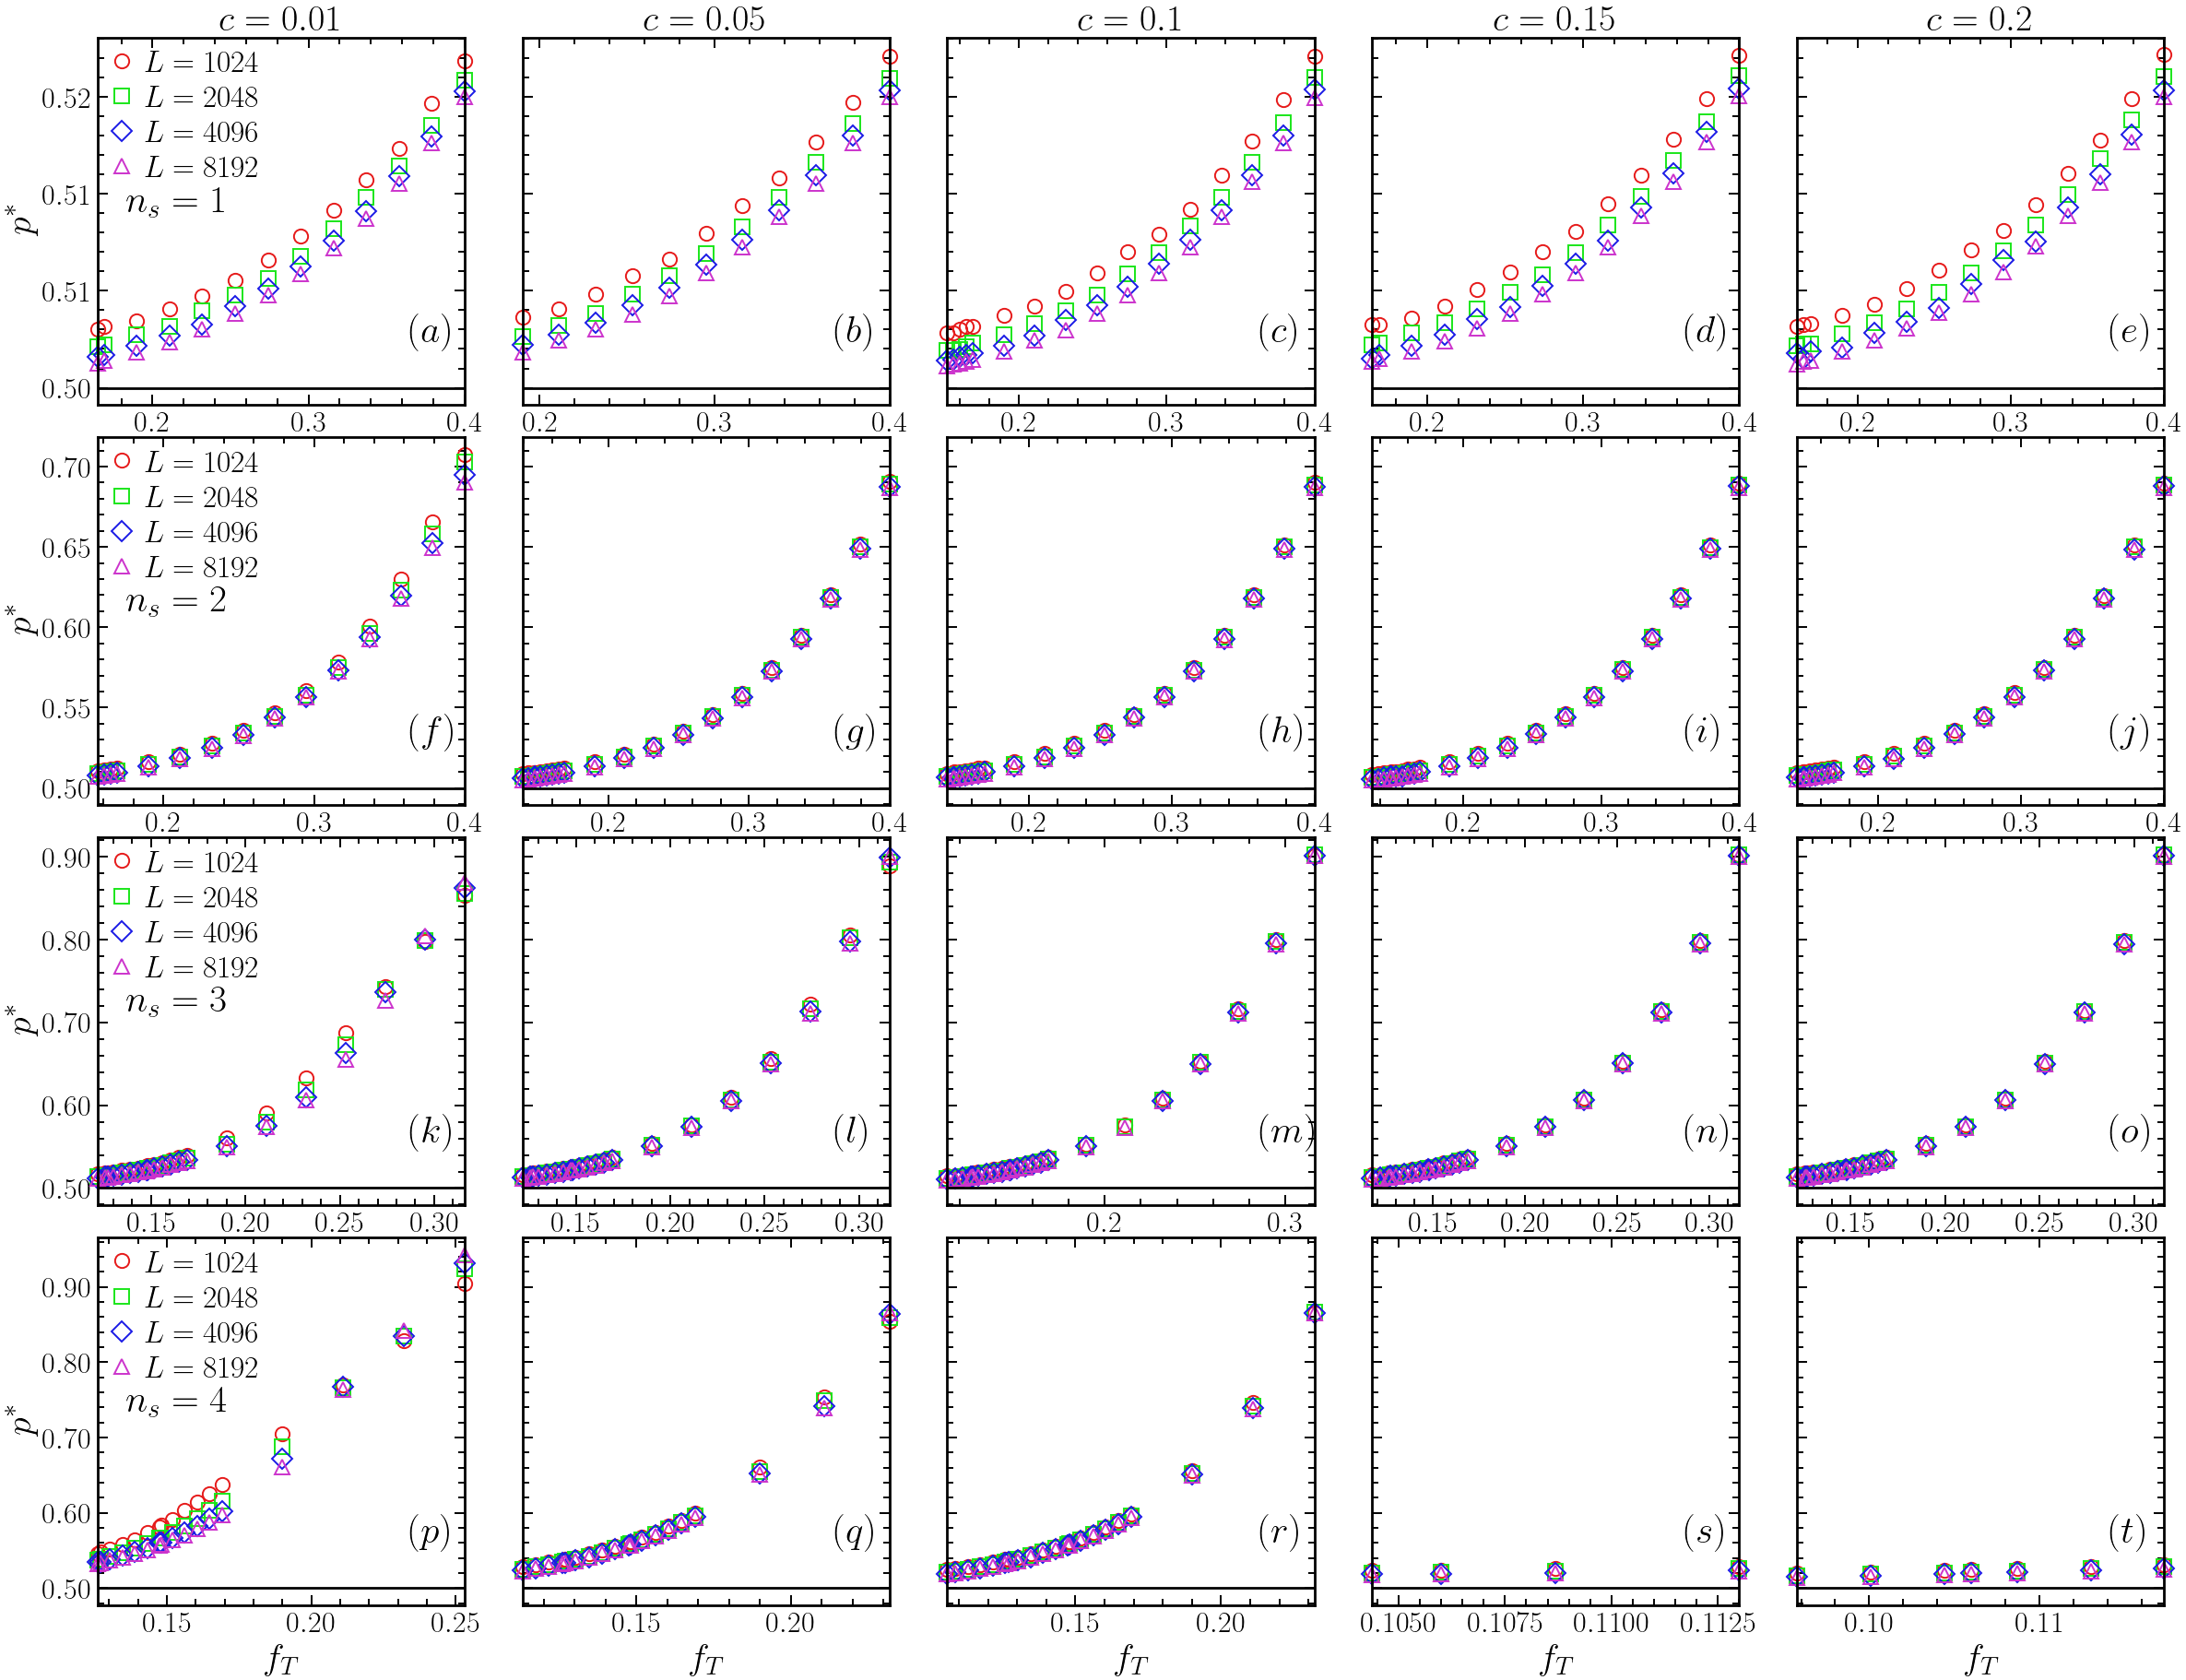

In [16]:
# PLOT <p_mean>
fig, axes, parms, ft_bounds = plot_pmean_series_grid(
    df_dynamic=df_dynamic,
    df_series=df_series,
    L_lst=[1024, 2048, 4096, 8192],
    ns_lst=[1, 2, 3, 4],
    c_lst=[0.01, 0.05, 0.1, 0.15, 0.2],
    window=300,
    base=5,
    dim=2,
    order=0,
    p0=0.8,
    wspace=0.01,
    hspace=0.09,
    legend_loc='upper left',
    tick_fs=23,
    label_fs=29,
    title_fs=29,
    ms=11,
    mew=1.4,
    print_bounds=True,
    fs_legend=24,
    ns_text_x=0.08,
    ns_text_y=0.60,
    ns_text_fs=30,
    panel_label_x=0.85,
    panel_label_y=0.25,
    panel_label_fs=30,
    savepath=results_folder + '/p_mean.pdf',
)

plt.show()

In [17]:
df_parms = pd.DataFrame(data=parms)
df_parms

,c,ft_min,ft_max,ns,dim,p0
0,0.01,0.164692,0.400000,1,2,0.8
1,0.05,0.190000,0.400000,1,2,0.8
2,0.10,0.151769,0.400000,1,2,0.8
3,0.15,0.164692,0.400000,1,2,0.8
4,0.20,0.160385,0.400000,1,2,0.8
5,0.01,0.156077,0.400000,2,2,0.8
6,0.05,0.138846,0.400000,2,2,0.8
7,0.10,0.143154,0.400000,2,2,0.8
8,0.15,0.134539,0.400000,2,2,0.8
9,0.20,0.143154,0.400000,2,2,0.8
